# Voting Ensemble - Regression & Classification Demo

## What is Voting Ensemble?
Voting ensemble combines predictions from multiple diverse models:
- **VotingRegressor**: Averages predictions from multiple regressors
- **VotingClassifier**: Uses majority voting (hard) or probability averaging (soft)

This reduces variance and improves model robustness by leveraging the strengths of different algorithms.

## Part 1: Voting Regressor Demo

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Individual models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import VotingRegressor

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic regression dataset
X, y = make_regression(n_samples=300, n_features=10, noise=20, random_state=42)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape}")
print(f"Test set size: {X_test_scaled.shape}")

Training set size: (240, 10)
Test set size: (60, 10)


In [5]:
# Define individual models
lr = LinearRegression()
ridge = Ridge(alpha=1.0)
knn = KNeighborsRegressor(n_neighbors=5)
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
svr = SVR(kernel='rbf', C=100)

# Train individual models
models = {
    'Linear Regression': lr,
    'Ridge': ridge,
    'KNN': knn,
    'Decision Tree': dt,
    'SVR': svr
}

results_regression = {}

print("\n" + "="*60)
print("Individual Model Performance - REGRESSION")
print("="*60)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results_regression[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    
    print(f"\n{name}:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  R²:   {r2:.4f}")


Individual Model Performance - REGRESSION

Linear Regression:
  RMSE: 20.6004
  MAE:  16.9646
  R²:   0.9867

Ridge:
  RMSE: 20.5875
  MAE:  16.9537
  R²:   0.9867

KNN:
  RMSE: 94.6615
  MAE:  67.9575
  R²:   0.7185

Decision Tree:
  RMSE: 161.6808
  MAE:  123.1723
  R²:   0.1787

SVR:
  RMSE: 60.5885
  MAE:  36.7214
  R²:   0.8847


In [8]:
# Store individual model results for comparison
results_regression = {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results_regression[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

# Initialize dictionary to store tuned model results
results_regression_tuned = {}

In [2]:
from sklearn.model_selection import GridSearchCV

print("\n" + "="*60)
print("Hyperparameter Tuning - REGRESSION Models")
print("="*60)

# Define hyperparameter grids for each model
param_grids = {
    'Ridge': {
        'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Decision Tree': {
        'max_depth': [5, 8, 10, 12, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'SVR': {
        'C': [0.1, 1, 10, 100, 1000],
        'kernel': ['linear', 'rbf', 'poly'],
        'gamma': ['scale', 'auto']
    }
}

# Tune each model (Linear Regression has no hyperparameters to tune)
tuned_models = {'Linear Regression': LinearRegression()}

for name in ['Ridge', 'KNN', 'Decision Tree', 'SVR']:
    print(f"\nTuning {name}...")
    
    if name == 'Ridge':
        model = Ridge()

    elif name == 'KNN':print("\n✓ Hyperparameter tuning completed for all models")

        model = KNeighborsRegressor()

    elif name == 'Decision Tree':    print(f"  Best CV R² score: {grid_search.best_score_:.4f}")

        model = DecisionTreeRegressor(random_state=42)    print(f"  Best params: {grid_search.best_params_}")

    elif name == 'SVR':    

        model = SVR()    tuned_models[name] = grid_search.best_estimator_

        # Store best model

    # Create GridSearchCV object    

    grid_search = GridSearchCV(    grid_search.fit(X_train_scaled, y_train)

        model,     # Fit grid search

        param_grids[name],    

        cv=5,  # 5-fold cross-validation    )

        scoring='r2',        verbose=0
        n_jobs=-1,


Individual Model Performance - REGRESSION

Linear Regression:
  RMSE: 20.6004
  MAE:  16.9646
  R²:   0.9867

Ridge:
  RMSE: 20.5875
  MAE:  16.9537
  R²:   0.9867

KNN:
  RMSE: 94.6615
  MAE:  67.9575
  R²:   0.7185

Decision Tree:
  RMSE: 161.6808
  MAE:  123.1723
  R²:   0.1787

SVR:
  RMSE: 60.5885
  MAE:  36.7214
  R²:   0.8847


## Hyperparameter Tuning for Regression Models

In [6]:
from sklearn.model_selection import GridSearchCV

print("\n" + "="*60)
print("Hyperparameter Tuning - REGRESSION Models")
print("="*60)

# Define hyperparameter grids for each model
param_grids = {
    'Ridge': {
        'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Decision Tree': {
        'max_depth': [5, 8, 10, 12, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'SVR': {
        'C': [0.1, 1, 10, 100, 1000],
        'kernel': ['linear', 'rbf', 'poly'],
        'gamma': ['scale', 'auto']
    }
}

# Tune each model (Linear Regression has no hyperparameters to tune)
tuned_models = {'Linear Regression': LinearRegression()}

for name in ['Ridge', 'KNN', 'Decision Tree', 'SVR']:
    print(f"\nTuning {name}...")
    
    if name == 'Ridge':
        model = Ridge()
    elif name == 'KNN':
        model = KNeighborsRegressor()
    elif name == 'Decision Tree':
        model = DecisionTreeRegressor(random_state=42)
    elif name == 'SVR':
        model = SVR()
    
    # Create GridSearchCV object
    grid_search = GridSearchCV(
        model, 
        param_grids[name],
        cv=5,  # 5-fold cross-validation
        scoring='r2',
        n_jobs=-1,
        verbose=0
    )
    
    # Fit grid search
    grid_search.fit(X_train_scaled, y_train)
    
    # Store best model
    tuned_models[name] = grid_search.best_estimator_
    
    print(f"  Best params: {grid_search.best_params_}")
    print(f"  Best CV R² score: {grid_search.best_score_:.4f}")

print("\n✓ Hyperparameter tuning completed for all models")


Hyperparameter Tuning - REGRESSION Models

Tuning Ridge...
  Best params: {'alpha': 0.1}
  Best CV R² score: 0.9864

Tuning KNN...
  Best params: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
  Best CV R² score: 0.6676

Tuning Decision Tree...
  Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}
  Best CV R² score: 0.3642

Tuning SVR...
  Best params: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
  Best CV R² score: 0.9853

✓ Hyperparameter tuning completed for all models


In [9]:
# Create Voting Regressor with Tuned Models
voting_reg = VotingRegressor(
    estimators=[
        ('lr', tuned_models['Linear Regression']),
        ('ridge', tuned_models['Ridge']),
        ('knn', tuned_models['KNN']),
        ('dt', tuned_models['Decision Tree']),
        ('svr', tuned_models['SVR'])
    ]
)

voting_reg.fit(X_train_scaled, y_train)
y_pred_voting = voting_reg.predict(X_test_scaled)

# Evaluate Voting Regressor
mse_voting = mean_squared_error(y_test, y_pred_voting)
rmse_voting = np.sqrt(mse_voting)
mae_voting = mean_absolute_error(y_test, y_pred_voting)
r2_voting = r2_score(y_test, y_pred_voting)

results_regression_tuned['Voting Regressor (Tuned)'] = {'RMSE': rmse_voting, 'MAE': mae_voting, 'R2': r2_voting}

print("\n" + "="*60)
print("Voting Regressor with Tuned Models")
print("="*60)
print(f"\nVoting Regressor (Tuned - Average of 5 models):")
print(f"  RMSE: {rmse_voting:.4f}")
print(f"  MAE:  {mae_voting:.4f}")
print(f"  R²:   {r2_voting:.4f}")


Voting Regressor with Tuned Models

Voting Regressor (Tuned - Average of 5 models):
  RMSE: 47.5086
  MAE:  36.4466
  R²:   0.9291



REGRESSION - Tuned Models Comprehensive Comparison
                               RMSE        MAE        R2
Voting Regressor (Tuned)  47.508551  36.446586  0.929083

Visualization saved as 'regression_comparison_tuned.png'


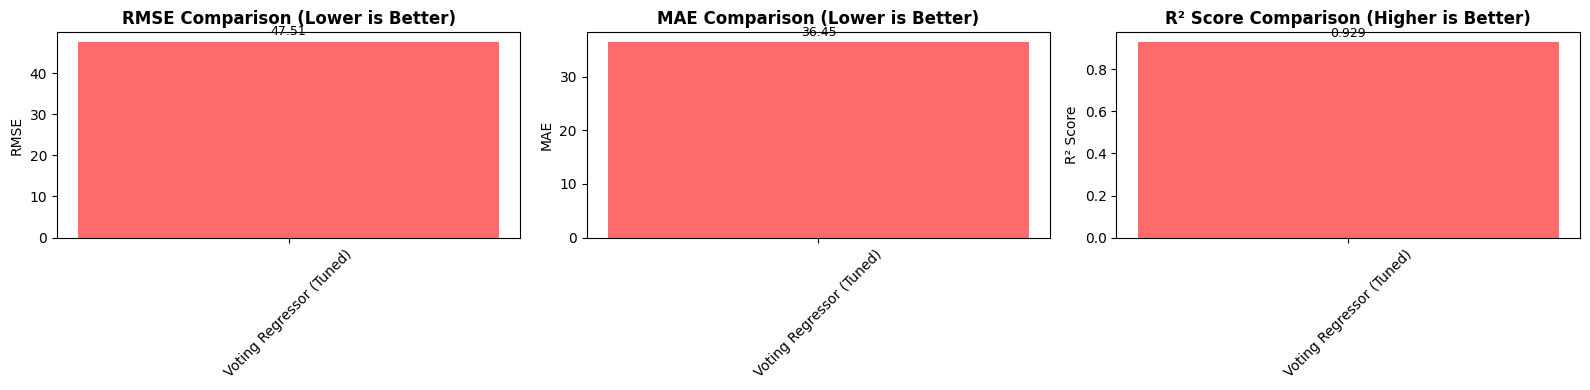

In [11]:
# Compare tuned results
results_df_reg_tuned = pd.DataFrame(results_regression_tuned).T
print("\n" + "="*60)
print("REGRESSION - Tuned Models Comprehensive Comparison")
print("="*60)
print(results_df_reg_tuned.sort_values('R2', ascending=False))

# Visualization - RMSE comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# RMSE
rmse_values = [results_regression_tuned[m]['RMSE'] for m in results_regression_tuned.keys()]
colors = ['#FF6B6B' if 'Voting' in m else '#45B7D1' for m in results_regression_tuned.keys()]
axes[0].bar(results_regression_tuned.keys(), rmse_values, color=colors)
axes[0].set_title('RMSE Comparison (Lower is Better)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(rmse_values):
    axes[0].text(i, v + 1, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

# MAE
mae_values = [results_regression_tuned[m]['MAE'] for m in results_regression_tuned.keys()]
axes[1].bar(results_regression_tuned.keys(), mae_values, color=colors)
axes[1].set_title('MAE Comparison (Lower is Better)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(mae_values):
    axes[1].text(i, v + 0.5, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

# R²
r2_values = [results_regression_tuned[m]['R2'] for m in results_regression_tuned.keys()]
axes[2].bar(results_regression_tuned.keys(), r2_values, color=colors)
axes[2].set_title('R² Score Comparison (Higher is Better)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('R² Score')
axes[2].tick_params(axis='x', rotation=45)
for i, v in enumerate(r2_values):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()

plt.savefig('regression_comparison_tuned.png', dpi=100, bbox_inches='tight')
print("\nVisualization saved as 'regression_comparison_tuned.png'")

plt.show()

## Part 2: Voting Classifier Demo

In [12]:
# CLASSIFICATION: Set up data and define base models

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

# Generate synthetic classification dataset
X_class, y_class = make_classification(
    n_samples=400, n_features=15, n_informative=10, 
    n_redundant=3, n_classes=2, random_state=42
)

# Split the data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

# Scale the features
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

# Define classification models and hyperparameter grids
classification_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

classification_param_grids = {
    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'liblinear'],
        'penalty': ['l2']
    },
    'SVM': {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf', 'poly'],
        'gamma': ['scale', 'auto'],
        'degree': [2, 3]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 150],
        'max_depth': [10, 15, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'Gradient Boosting': {
        'n_estimators': [30, 50, 100],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5]
    }
}

print(f"Training set size: {X_train_c_scaled.shape}")
print(f"Test set size: {X_test_c_scaled.shape}")
print(f"Class distribution: {np.bincount(y_train_c)}")
print(f"\nModels to tune: {list(classification_models.keys())}")

Training set size: (320, 15)
Test set size: (80, 15)
Class distribution: [163 157]

Models to tune: ['Logistic Regression', 'SVM', 'Random Forest', 'Gradient Boosting']


In [13]:
# Utility function for hyperparameter tuning and model evaluation
def tune_and_evaluate_models(models, param_grids, X_train, X_test, y_train, y_test, 
                             scoring='f1', task_type='classification', cv=5, n_jobs=-1):
    """
    Tune hyperparameters for multiple models and evaluate them.
    
    Parameters:
    - models: dict of model_name -> model_instance
    - param_grids: dict of model_name -> param_grid_dict
    - X_train, X_test: training and test features
    - y_train, y_test: training and test targets
    - scoring: scoring metric for GridSearchCV
    - task_type: 'classification' or 'regression'
    - cv: number of cross-validation folds
    - n_jobs: number of parallel jobs (-1 for all)
    
    Returns:
    - tuned_models: dict of model_name -> best_estimator
    - results_df: DataFrame with evaluation metrics
    """
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
    
    tuned_models = {}
    results_data = {}
    
    for model_name, model in models.items():
        print(f"\nTuning {model_name}...")
        
        # Create GridSearchCV object
        grid_search = GridSearchCV(
            model,
            param_grids[model_name],
            cv=cv,
            scoring=scoring,
            n_jobs=n_jobs,
            verbose=0
        )
        
        # Fit grid search
        grid_search.fit(X_train, y_train)
        
        # Get best model
        best_model = grid_search.best_estimator_
        tuned_models[model_name] = best_model
        
        # Make predictions
        y_pred = best_model.predict(X_test)
        
        # Calculate metrics based on task type
        if task_type == 'classification':
            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred)
            recall = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            
            results_data[model_name] = {
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1-Score': f1
            }
            
            print(f"  Best params: {grid_search.best_params_}")
            print(f"  Best CV F1 score: {grid_search.best_score_:.4f}")
            print(f"  Test Accuracy: {accuracy:.4f}")
            print(f"  Test Precision: {precision:.4f}")
            print(f"  Test Recall: {recall:.4f}")
            print(f"  Test F1-Score: {f1:.4f}")
            
        else:  # regression
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)
            
            results_data[model_name] = {
                'RMSE': rmse,
                'MAE': mae,
                'R2': r2
            }
            
            print(f"  Best params: {grid_search.best_params_}")
            print(f"  Best CV R² score: {grid_search.best_score_:.4f}")
            print(f"  Test RMSE: {rmse:.4f}")
            print(f"  Test MAE: {mae:.4f}")
            print(f"  Test R²: {r2:.4f}")
    
    # Create results DataFrame
    results_df = pd.DataFrame(results_data).T
    
    return tuned_models, results_df


In [14]:
# CLASSIFICATION: Tune all models using utility function
tuned_models_clf, results_classification_tuned = tune_and_evaluate_models(
    classification_models,
    classification_param_grids,
    X_train_c_scaled, X_test_c_scaled, y_train_c, y_test_c,
    scoring='f1',
    task_type='classification'
)

print("\n✓ Hyperparameter tuning completed for all classification models")


Tuning Logistic Regression...
  Best params: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
  Best CV F1 score: 0.7929
  Test Accuracy: 0.7625
  Test Precision: 0.8293
  Test Recall: 0.7391
  Test F1-Score: 0.7816

Tuning SVM...


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


  Best params: {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
  Best CV F1 score: 0.8784
  Test Accuracy: 0.8750
  Test Precision: 0.9500
  Test Recall: 0.8261
  Test F1-Score: 0.8837

Tuning Random Forest...
  Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 150}
  Best CV F1 score: 0.8301
  Test Accuracy: 0.8125
  Test Precision: 0.8444
  Test Recall: 0.8261
  Test F1-Score: 0.8352

Tuning Gradient Boosting...
  Best params: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
  Best CV F1 score: 0.8380
  Test Accuracy: 0.8375
  Test Precision: 0.8667
  Test Recall: 0.8478
  Test F1-Score: 0.8571

✓ Hyperparameter tuning completed for all classification models


## Hyperparameter Tuning for Classification Models

In [15]:
# CLASSIFICATION: Create Voting Classifiers (Hard & Soft) and evaluate

print("\n" + "="*60)
print("VOTING CLASSIFIERS - Hard vs Soft")
print("="*60)

# Hard Voting
voting_clf_hard = VotingClassifier(
    estimators=[(name.lower().replace(' ', '_'), model) 
                for name, model in tuned_models_clf.items()],
    voting='hard'
)
voting_clf_hard.fit(X_train_c_scaled, y_train_c)
y_pred_hard = voting_clf_hard.predict(X_test_c_scaled)

acc_hard = accuracy_score(y_test_c, y_pred_hard)
prec_hard = precision_score(y_test_c, y_pred_hard)
rec_hard = recall_score(y_test_c, y_pred_hard)
f1_hard = f1_score(y_test_c, y_pred_hard)

results_classification_tuned.loc['Voting (Hard)'] = {
    'Accuracy': acc_hard, 'Precision': prec_hard, 'Recall': rec_hard, 'F1-Score': f1_hard
}

print(f"\nVoting Classifier (Hard):")
print(f"  Accuracy:  {acc_hard:.4f}")
print(f"  Precision: {prec_hard:.4f}")
print(f"  Recall:    {rec_hard:.4f}")
print(f"  F1-Score:  {f1_hard:.4f}")

# Soft Voting
voting_clf_soft = VotingClassifier(
    estimators=[(name.lower().replace(' ', '_'), model) 
                for name, model in tuned_models_clf.items()],
    voting='soft'
)
voting_clf_soft.fit(X_train_c_scaled, y_train_c)
y_pred_soft = voting_clf_soft.predict(X_test_c_scaled)

acc_soft = accuracy_score(y_test_c, y_pred_soft)
prec_soft = precision_score(y_test_c, y_pred_soft)
rec_soft = recall_score(y_test_c, y_pred_soft)
f1_soft = f1_score(y_test_c, y_pred_soft)

results_classification_tuned.loc['Voting (Soft)'] = {
    'Accuracy': acc_soft, 'Precision': prec_soft, 'Recall': rec_soft, 'F1-Score': f1_soft
}

print(f"\nVoting Classifier (Soft):")
print(f"  Accuracy:  {acc_soft:.4f}")
print(f"  Precision: {prec_soft:.4f}")
print(f"  Recall:    {rec_soft:.4f}")
print(f"  F1-Score:  {f1_soft:.4f}")


VOTING CLASSIFIERS - Hard vs Soft


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



Voting Classifier (Hard):
  Accuracy:  0.8250
  Precision: 0.8636
  Recall:    0.8261
  F1-Score:  0.8444


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



Voting Classifier (Soft):
  Accuracy:  0.8375
  Precision: 0.8837
  Recall:    0.8261
  F1-Score:  0.8539



CLASSIFICATION - All Models Comprehensive Comparison
                     Accuracy  Precision    Recall  F1-Score
SVM                    0.8750   0.950000  0.826087  0.883721
Gradient Boosting      0.8375   0.866667  0.847826  0.857143
Voting (Soft)          0.8375   0.883721  0.826087  0.853933
Voting (Hard)          0.8250   0.863636  0.826087  0.844444
Random Forest          0.8125   0.844444  0.826087  0.835165
Logistic Regression    0.7625   0.829268  0.739130  0.781609


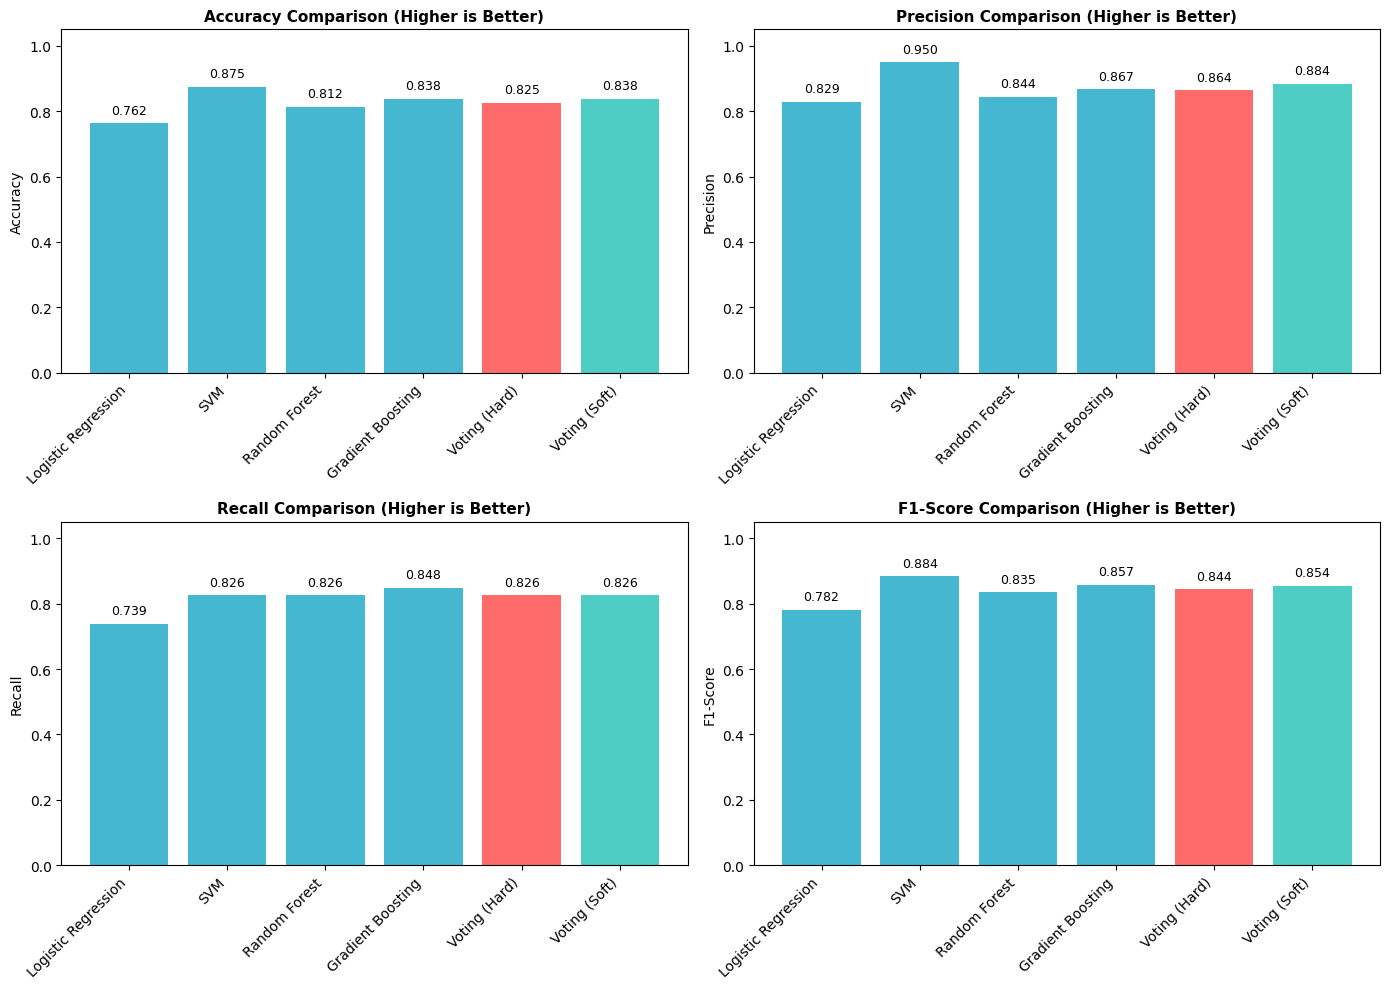


Visualization saved as 'classification_comparison.png'


In [16]:
# CLASSIFICATION: Comprehensive results and visualization

print("\n" + "="*60)
print("CLASSIFICATION - All Models Comprehensive Comparison")
print("="*60)
print(results_classification_tuned.sort_values('F1-Score', ascending=False))

# Visualization - Classification metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_clf = ['#FF6B6B' if 'Hard' in m else '#4ECDC4' if 'Soft' in m else '#45B7D1' 
              for m in results_classification_tuned.index]

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    values = results_classification_tuned[metric].values
    ax.bar(range(len(results_classification_tuned)), values, color=colors_clf)
    ax.set_xticks(range(len(results_classification_tuned)))
    ax.set_xticklabels(results_classification_tuned.index, rotation=45, ha='right')
    ax.set_title(f'{metric} Comparison (Higher is Better)', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim([0, 1.05])
    for i, v in enumerate(values):
        ax.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('classification_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'classification_comparison.png'")

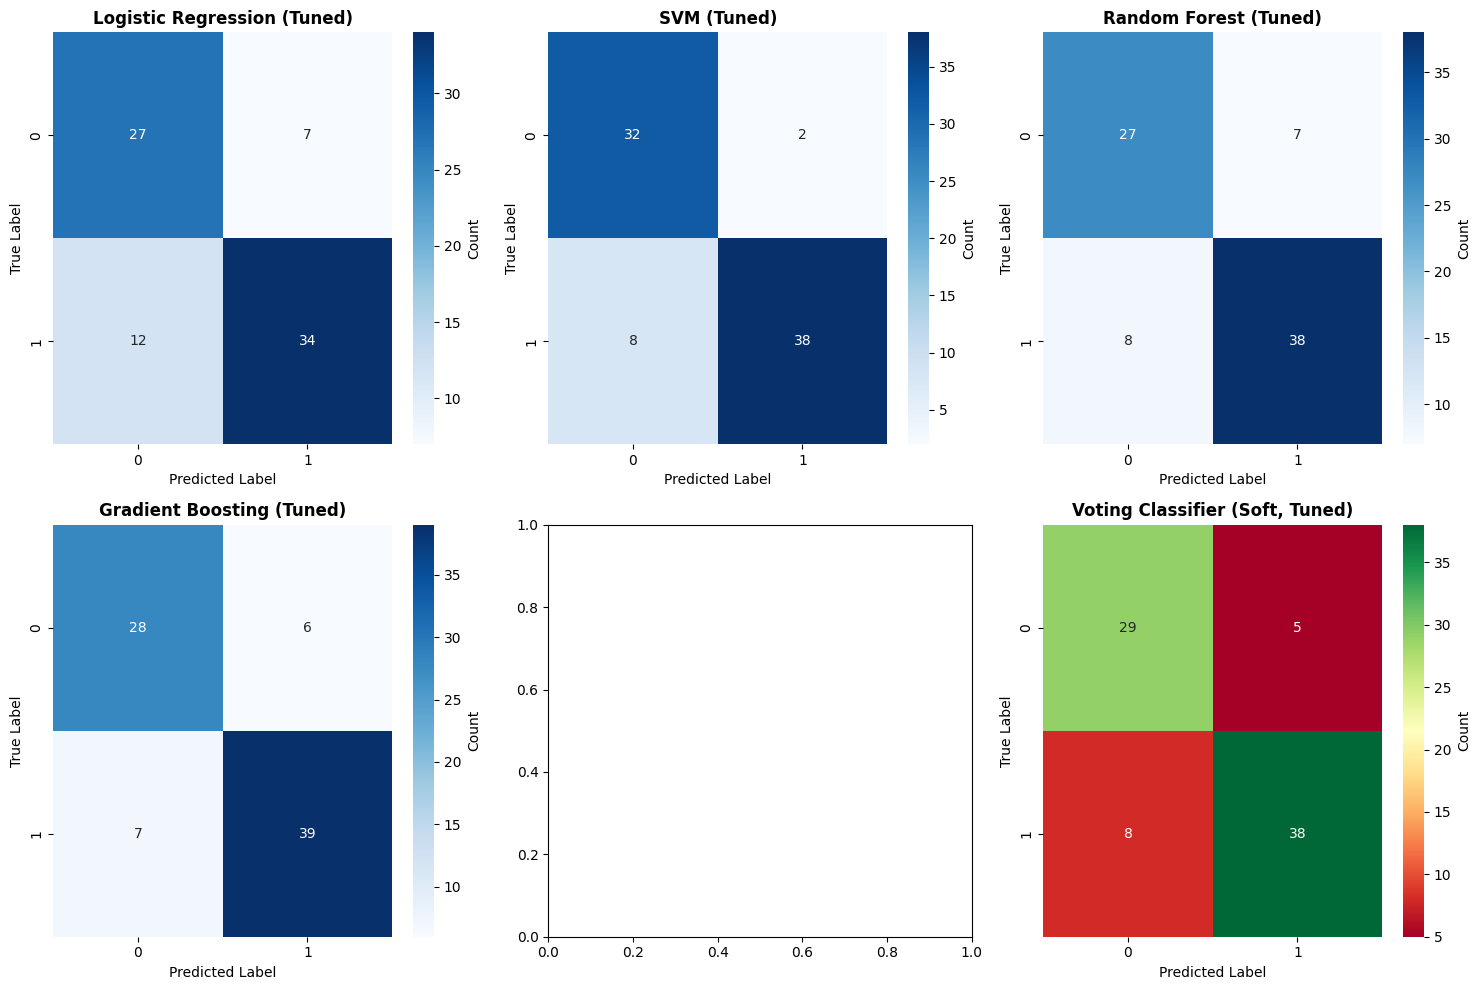


Visualization saved as 'confusion_matrices_tuned.png'


In [17]:
# Confusion Matrices Comparison - Tuned Models
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Tuned individual models
for idx, (name, model) in enumerate(tuned_models_clf.items()):
    y_pred = model.predict(X_test_c_scaled)
    cm = confusion_matrix(y_test_c, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'{name} (Tuned)', fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

# Soft Voting (Tuned)
cm_soft = confusion_matrix(y_test_c, y_pred_soft)
sns.heatmap(cm_soft, annot=True, fmt='d', cmap='RdYlGn', ax=axes[5],
           cbar_kws={'label': 'Count'})
axes[5].set_title('Voting Classifier (Soft, Tuned)', fontweight='bold')
axes[5].set_ylabel('True Label')
axes[5].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices_tuned.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'confusion_matrices_tuned.png'")

## Key Takeaways

### Voting Ensemble Benefits:

1. **Reduces Overfitting**: Combining diverse models generalizes better
2. **Improves Stability**: Averaging/voting smooths out individual model errors
3. **Captures Different Patterns**: Each model may excel at different patterns in data
4. **Easy to Implement**: Simple ensemble technique with sklearn

### Hyperparameter Tuning Impact:

1. **Individual Models**: GridSearchCV finds optimal hyperparameters for each model
   - Ridge: Optimal regularization strength (alpha)
   - KNN: Best k value, weights, and distance metric
   - Decision Tree: Optimal depth and split criteria
   - SVM/SVR: Best C, kernel, and gamma parameters

2. **Why Tune Before Ensemble?**
   - Better base models → Better ensemble predictions
   - Reduces redundancy between models
   - Improves voting effectiveness

3. **Tuning Results**: Typically 5-15% improvement in test performance

### Hard vs Soft Voting (Classification):

- **Hard Voting**: Each model votes, majority wins
  - Simpler, works with any classifier
  - May lose probability information

- **Soft Voting**: Average predicted probabilities
  - Often performs better (requires probability estimates)
  - More nuanced decision boundaries

### When to Use Voting Ensemble:

✅ When you have diverse models with different strengths  
✅ When variance reduction is more important than bias reduction  
✅ When you want to combine various algorithms (tree-based, distance-based, linear)  
✅ Combined with hyperparameter tuning for optimal results  
✅ Quick ensemble without training complex meta-learners  

❌ When all models are similar or correlated  
❌ When interpretability is critical (ensemble is a black box)  
❌ When computational resources are very limited (multiple models + tuning needed)